# Behavior plots — interactive

Per-animal behavior diagnostics for one or more animals in a dataset. The single selection cell in section 2 is the only thing to edit when switching datasets or animals; everything downstream — load and the per-animal outputs — works against whatever the selection cell defined. Section 4 cells are thin caller stubs over `sollertia_forgery.analysis.behavior.plotting`; edit the helpers in the package and re-run the affected cell to refresh.

Unlike bleaching / tuning / drift, the behavior package persists no per-animal report. Section 3 walks each animal's sessions on the fly, calling `aggregate_lick_events` directly against `data.feather` and the per-session trial geometry data file.

## 1. Setup

Imports for the rest of the notebook. Run once per kernel restart; `%autoreload` keeps package edits live so re-running the section 4 cells picks up plotting helper changes without reloading.

In [33]:
%matplotlib inline
%load_ext autoreload
%autoreload 2

from pathlib import Path

import matplotlib.pyplot as plt
from ataraxis_base_utilities import LogLevel, console

from sollertia_forgery.shared_assets import DatasetData
from sollertia_forgery.analysis import (
    LickContext,
    TrialOutcomeContext,
    aggregate_lick_events,
    aggregate_trial_outcomes,
    plot_lick_scatter,
    plot_trial_outcomes,
)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## 2. Selection

The only cell to edit when switching datasets or animals. `DATASET_PATH` is the dataset root; `ANIMALS` is either a tuple of animal ids (`("11", "15", "16")`) or `None` to load every animal in the dataset; `DISPLAY_SESSIONS` is a tuple of 1-indexed chronological session numbers shared by every per-animal plot below — set it to `None` to render every session in each animal's context.

In [34]:
DATASET_PATH: Path = Path("/home/data/Data/void")
ANIMALS: tuple[str, ...] | None = ("16",)
DISPLAY_SESSIONS: tuple[int, ...] | None = (15,16,17,18,19,20)

## 3. Load

Reads the dataset and assembles `contexts`, the per-animal `dict[str, LickContext]` consumed by every plot cell. Each animal's contiguous session sequence is sorted chronologically and passed through `aggregate_lick_events`; animals with zero sessions are skipped with a warning so partial datasets still load.

In [35]:
dataset = DatasetData.load(dataset_path=DATASET_PATH)
resolved_animals: tuple[str, ...] = (
    tuple(dataset_animal.animal for dataset_animal in dataset.animals)
    if ANIMALS is None
    else ANIMALS
)

lick_contexts: dict[str, LickContext] = {}
outcome_contexts: dict[str, TrialOutcomeContext] = {}
for animal_id in resolved_animals:
    animal_sessions = tuple(
        sorted(
            dataset.get_sessions_for_animal(animal=animal_id),
            key=lambda dataset_session: dataset_session.session,
        )
    )
    if not animal_sessions:
        console.echo(
            message=f"animal {animal_id}: no sessions; skipping",
            level=LogLevel.WARNING,
        )
        continue
    lick_contexts[animal_id] = aggregate_lick_events(sessions=animal_sessions)
    outcome_contexts[animal_id] = aggregate_trial_outcomes(sessions=animal_sessions)

console.echo(message=f"Dataset: {dataset.name} ({DATASET_PATH})", level=LogLevel.INFO)
console.echo(
    message=f"Loaded {len(lick_contexts)} animal context(s) for: {', '.join(lick_contexts) or '<none>'}",
    level=LogLevel.INFO,
)

2026-05-03 12:33:32.395 | INFO     | Dataset: void (/home/data/Data/void)
2026-05-03 12:33:32.395 | INFO     | Loaded 1 animal context(s) for: 16


## 4. Per-animal outputs

Each cell below loops over `contexts` and calls one helper from `sollertia_forgery.analysis.behavior.plotting`. Helpers return `matplotlib.figure.Figure`; the notebook just calls `plt.show()` so the figures render inline.

### 4.1 Lick scatter

Discrete rising-edge lick events scattered in (within-trial position, cumulative trial index) coordinates, with per-trial reward-zone rectangles drawn from each block's resolved geometry. Trial-type and geometry shifts (longitudinal mid-recording reward-zone shifts or intra-session multi-trial-type recordings) appear as different per-trial rectangles with the same color coding (rewarded vs non-rewarded relative to the trial's own reward zone).

Uses `DISPLAY_SESSIONS` from the selection cell to pick which sessions to render; leave it `None` there to render every session in each animal's context.

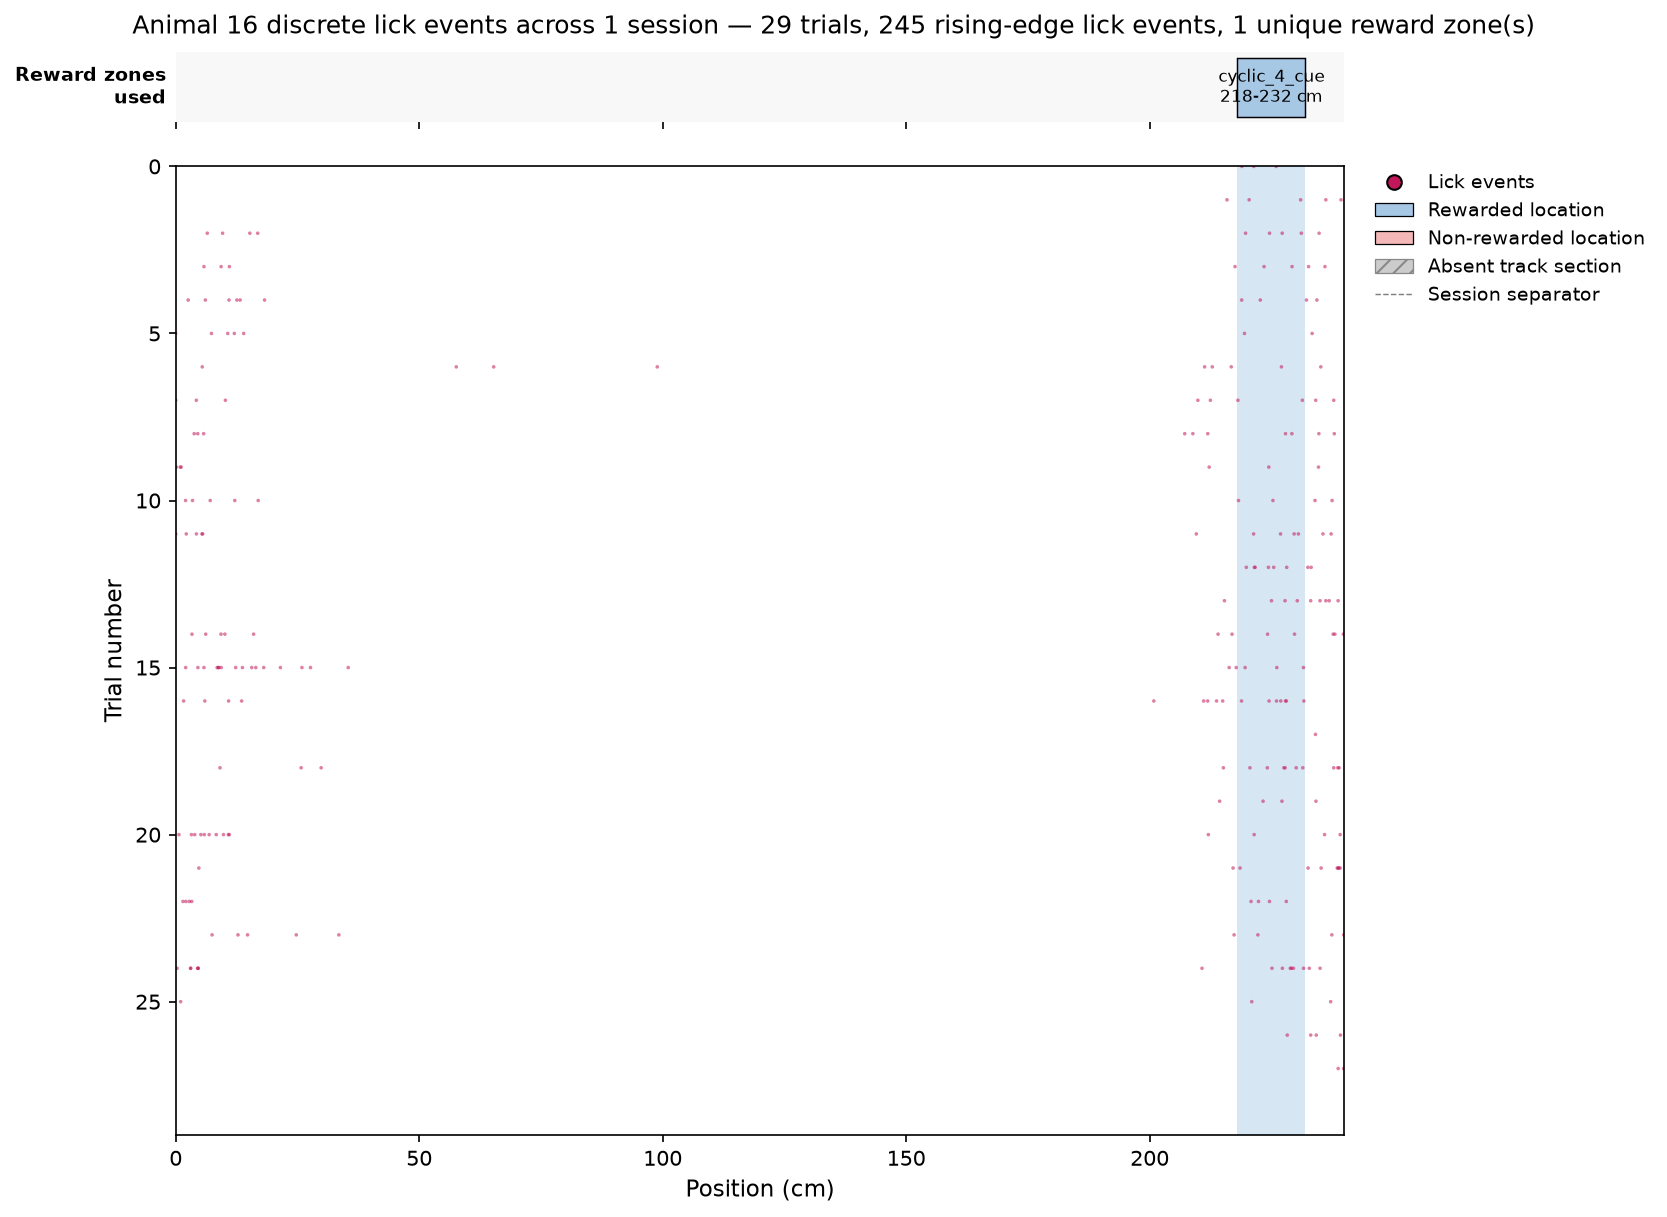

In [36]:
for animal_id, context in lick_contexts.items():
    plot_lick_scatter(
        context=context,
        animal_id=animal_id,
        display_sessions=DISPLAY_SESSIONS,
    )
    plt.show()

### 4.2 Trial outcomes across sessions

Per-session stacked bar chart of success / failure / guided trial counts for the animal, with a success-rate trace overlaid on a secondary y-axis. A trial is classified as **guided** when any of its samples has ``reinforcing_guided`` or ``aversive_guided`` set; **success** when the trial is not guided and any sample has ``reward > 0``; **failure** otherwise. Guided trials are excluded from the success-rate denominator so the rate tracks the animal's earned-reward fraction rather than reflecting training-phase guidance.

In [37]:
for animal_id, context in outcome_contexts.items():
    plot_trial_outcomes(
        context=context,
        animal_id=animal_id,
        display_sessions=DISPLAY_SESSIONS,
    )
    plt.show()

NameError: name 'TrialOutcomeContext' is not defined